In [1]:
import pandas

In [4]:
df = pandas.read_csv('https://raw.githubusercontent.com/Uwanga14/netflix_customer_churn/refs/heads/main/Model2.csv')

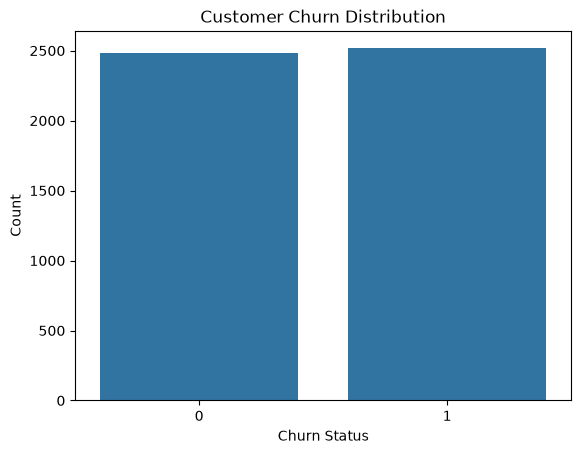

In [ ]:
#Show the number of churned vs retained subscribers.

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='churned')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Count')

plt.show()

### Customer Churn Distribution
 
Figure 1 shows the distribution of churned and retained customers in the Netflix Customer Churn Dataset. The dataset is relatively balanced, with approximately 2,500 retained customers (`0`) and 2,500 churned customers (`1`).
 
The balanced distribution of the target variable is beneficial for machine learning because it reduces the risk of model bias towards a particular class. As a result, the models are able to learn patterns associated with both churned and retained subscribers more effectively, leading to more reliable performance evaluation and prediction results.

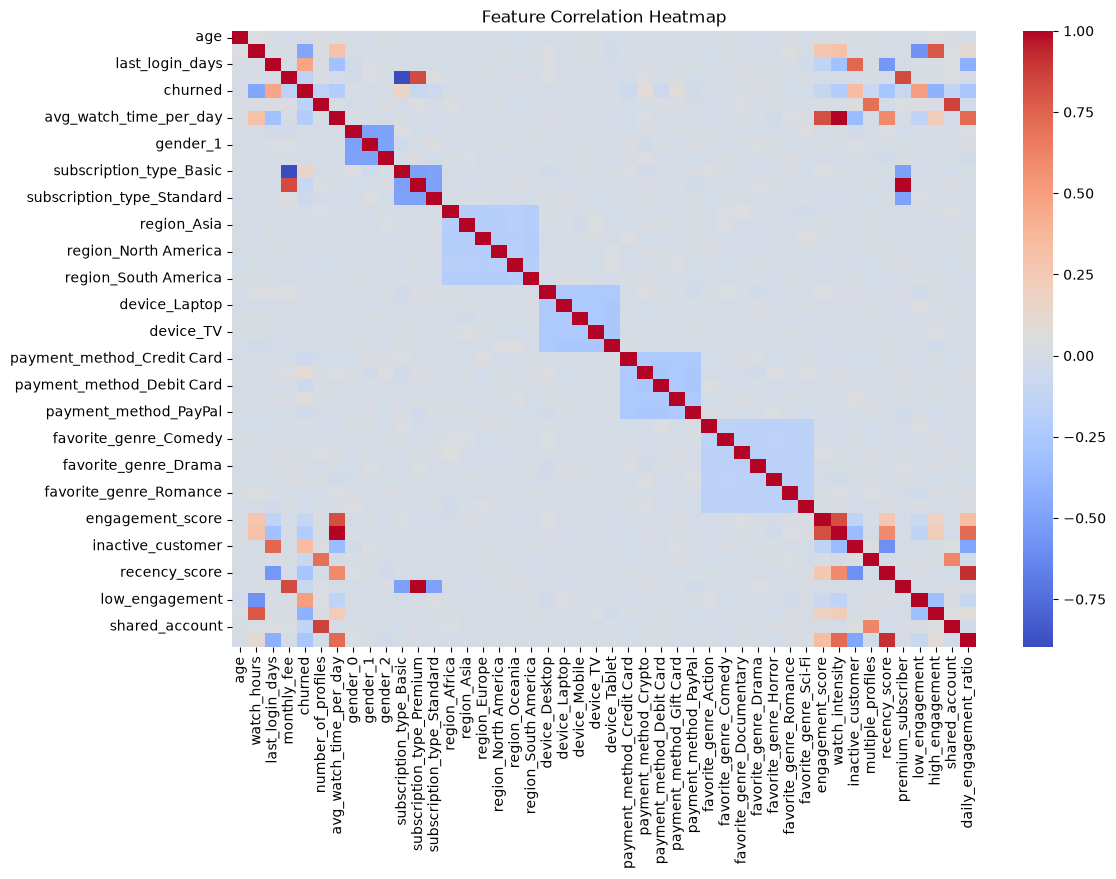

In [6]:
#Visualise the correlation between features using a heatmap.

plt.figure(figsize=(12,8))
 
sns.heatmap(
df.corr(numeric_only=True),
cmap='coolwarm'
)
 
plt.title('Feature Correlation Heatmap')
plt.show()

### Feature Correlation Heatmap
 
Figure 2 presents a correlation heatmap illustrating the relationships between the dataset features and the target variable (`churned`). Strong positive correlations are represented by warmer colours, while strong negative correlations are represented by cooler colours.
 
The heatmap confirms that customer engagement and activity-related variables have the strongest relationships with churn. Features such as **last_login_days**, **inactive_customer**, and **low_engagement** show positive associations with churn, indicating that less active subscribers are more likely to cancel their subscriptions. Conversely, **watch_hours**, **avg_watch_time_per_day**, **engagement_score**, and **watch_intensity** display negative relationships with churn, suggesting that highly engaged viewers are less likely to leave the platform.

In [10]:
X = df.drop('churned', axis=1)

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Features
X = df.drop('churned', axis=1)

# Target
y = df['churned']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [13]:
feature_importance = pandas.DataFrame({
'Feature': X.columns,
'Importance': rf_model.feature_importances_
})
 
feature_importance = feature_importance.sort_values(
by='Importance',
ascending=False
)
 
print(feature_importance.head(10))

                   Feature  Importance
1              watch_hours    0.188937
2          last_login_days    0.134868
39           recency_score    0.132810
41          low_engagement    0.100331
42         high_engagement    0.078018
4       number_of_profiles    0.048538
44  daily_engagement_ratio    0.037471
5   avg_watch_time_per_day    0.037020
35        engagement_score    0.033443
36         watch_intensity    0.030391


/tmp/ipykernel_19003/1531599297.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


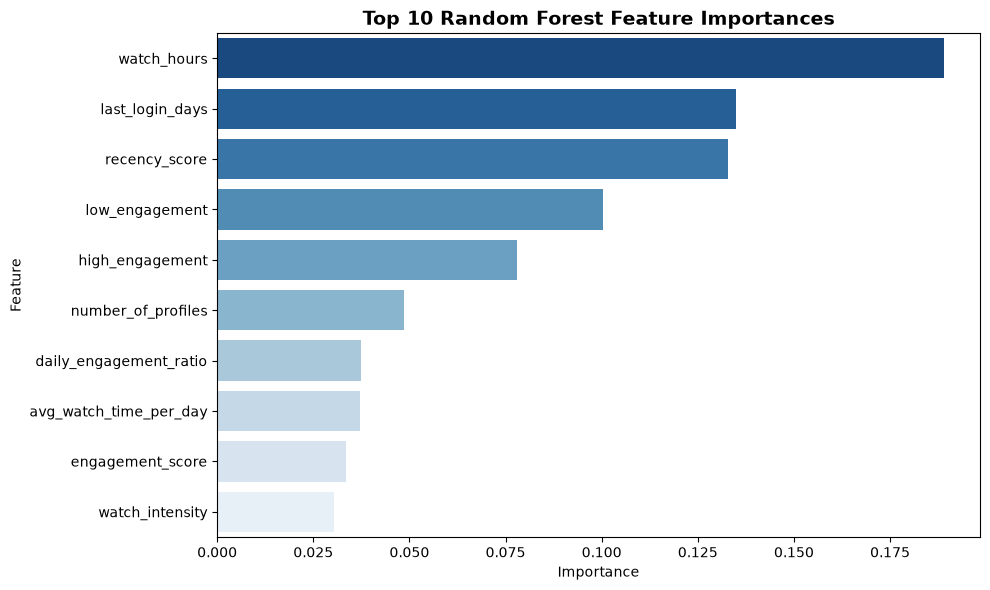

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature',
    palette='Blues_r'
)

plt.title(
    'Top 10 Random Forest Feature Importances',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()

plt.show()

### Random Forest Feature Importance
 
Figure 3 presents the top ten most important features identified by the Random Forest model. The results show that **watch_hours** was the strongest predictor of churn, followed by **last_login_days** and **recency_score**. These features contributed the most to the model's decision-making process, indicating that customer engagement and platform activity have the greatest influence on subscriber retention.
 
Additional important features included **low_engagement**, **high_engagement**, **number_of_profiles**, and **daily_engagement_ratio**. The prominence of these engagement-related variables suggests that customers who watch content frequently, log in regularly, and maintain consistent platform usage are significantly less likely to churn. These findings are consistent with the correlation analysis and support the conclusion that subscriber engagement is the primary driver of churn behaviour.